In [108]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

In [110]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

sc.settings.set_figure_params(dpi=80)
%matplotlib inline

from pathlib import Path

# Get the current working directory as a Path object
current_dir = Path.cwd()

print(f"Current Directory: {current_dir}")

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
# sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current Directory: C:\Users\Gabrielle\Documents\GitHub\20251021_Ctnnd2_MBP_Bcas1_Pdgfra_ASPA_analysis


In [112]:
df = pd.read_csv("./DATA/oligo_binned_proportions_totals.csv")
agg = df.copy()

In [114]:
agg = agg.rename(columns={
    'bin': 'bin_number',
    'oligo': 'total_in_bin',
    'mol': 'count_MOL',
    'int': 'count_INT',
    'opc': 'count_OPC'
})

agg = agg[
    ['animal', 'bin_number', 'total_in_bin',
     'count_MOL', 'count_INT', 'count_OPC']
]

counts_by_sample = {}
cell_types = ['MOL', 'INT', 'OPC']

for animal, subdf in agg.groupby('animal'):
    counts_by_sample[animal] = {}
    
    subdf = subdf.drop(columns='animal').reset_index(drop=True)
    
    counts_by_sample[animal] = subdf.copy()

counts_by_sample

{529551:    bin_number  total_in_bin  count_MOL  count_INT  count_OPC
 0           1            89          2         33         54
 1           2           144         41         52         50
 2           3           209         53        103         52
 3           4           207         54         84         67,
 529552:    bin_number  total_in_bin  count_MOL  count_INT  count_OPC
 0           1           113          2         16         95
 1           2           111          7         46         58
 2           3           157         31         52         74
 3           4           209         47         61         96,
 551941:    bin_number  total_in_bin  count_MOL  count_INT  count_OPC
 0           1           110          9         36         65
 1           2           142         32         55         55
 2           3           211         58         88         65
 3           4           277         70        141         66,
 551943:    bin_number  total_in_bin  count

In [116]:
# Combine samples to get total binned subtype counts per genotype
genotype_map = {'529552': 'KO', '551941': 'KO', '551944': 'KO', '529551': 'WT', '551943': 'WT', '551948': 'WT'}
genotype_map = {int(k): v for k, v in genotype_map.items()}
genotypes = ['WT','KO']

# Prepare empty DataFrames for aggregation
combined_counts = {
    g: pd.DataFrame(0, index=np.arange(4), columns=['bin_number','total_in_bin'] + [f'count_{ct}' for ct in cell_types])
    for g in genotypes
}

for sample_name, ct_dict in counts_by_sample.items():
    g = genotype_map[sample_name]
    # Total counts per bin are the same for each cell type, so we can take the first cell type for total_in_bin
    combined_counts[g]['total_in_bin'] += ct_dict['total_in_bin']
    combined_counts[g]['bin_number'] = ct_dict['bin_number']
    
    # Sum counts for each cell type
    for ct in cell_types:
        combined_counts[g][f'count_{ct}'] += ct_dict[f'count_{ct}']

In [118]:
from scipy.stats import chi2_contingency
import numpy as np

df_counts = pd.concat(combined_counts, names=['group']).reset_index(level=0)
print(df_counts.head(10))

df_counts = df_counts.set_index(['group', 'bin_number'])

# Reorder columns so Upper is plotted top of stack
df_counts = df_counts[['count_MOL', 'count_INT', 'count_OPC']]
df_prop = df_counts.div(df_counts.sum(axis=1), axis=0)

# Reshape index for grouped plotting
df_prop = df_prop.reset_index()
df_counts = df_counts.reset_index()

bins = sorted(df_prop['bin_number'].unique())
groups = ['WT', 'KO']

chi_labels = {}

for b in bins:
    sub = df_counts[df_counts['bin_number'] == b]

    wt = sub[sub['group'] == 'WT'][['count_MOL', 'count_INT', 'count_OPC']].values.flatten()
    ko = sub[sub['group'] == 'KO'][['count_MOL', 'count_INT', 'count_OPC']].values.flatten()

    contingency = np.vstack([wt, ko]).T  # layers × groups

    chi2, p, _, _ = chi2_contingency(contingency)

    chi_labels[b] = f"χ²={chi2:.1f}\np={p:.2g}"

  group  bin_number  total_in_bin  count_MOL  count_INT  count_OPC
0    WT           1           354         30        184        137
1    WT           2           418        108        191        116
2    WT           3           614        172        296        145
3    WT           4           656        213        269        167
0    KO           1           372         18        127        227
1    KO           2           405         73        178        151
2    KO           3           561        132        233        193
3    KO           4           722        195        297        222


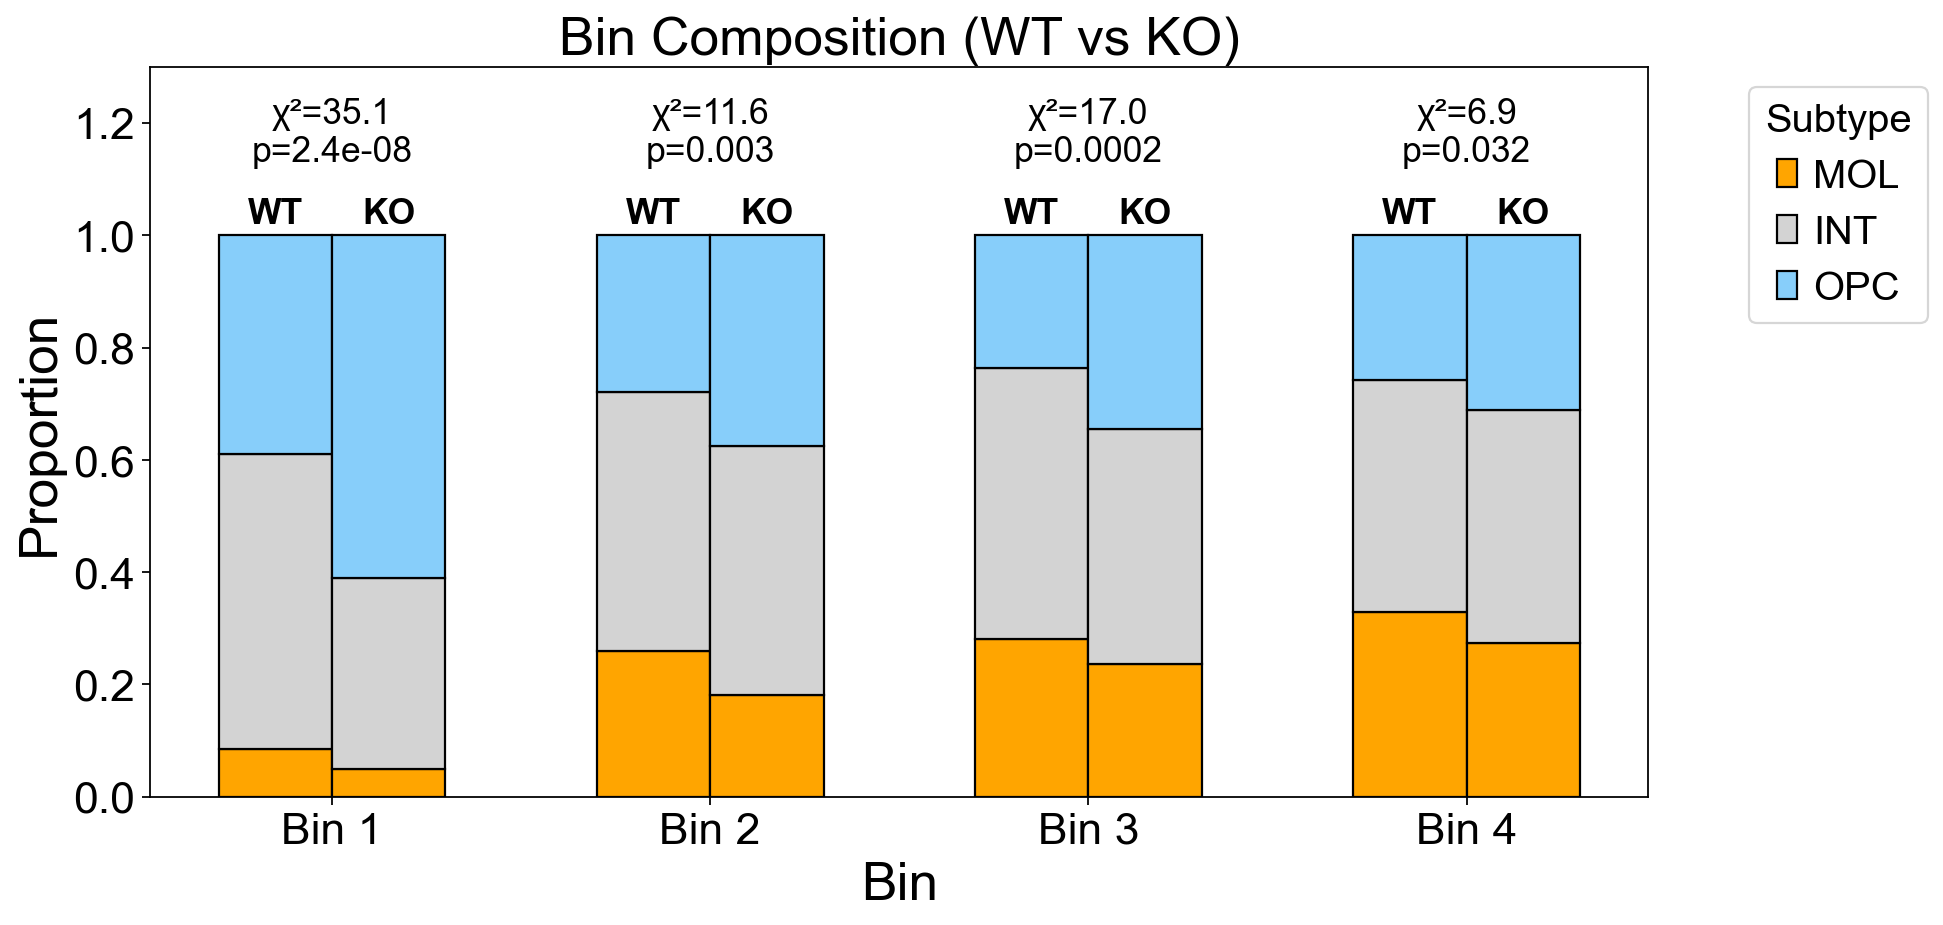

In [120]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
Path("plots").mkdir(exist_ok=True)

x = np.arange(len(bins))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['orange', 'lightgray', 'lightskyblue']  # MOL, INT, OPC

bar_tops = {}

# Loop through WT and KO
for i, group in enumerate(groups):
    dfp = df_prop[df_prop['group'] == group].set_index('bin_number').loc[bins]
    bar_tops[group] = dfp[['count_MOL', 'count_INT', 'count_OPC']].sum(axis=1).values
    dfc = df_counts[df_counts['group'] == group].set_index('bin_number').loc[bins]

    bottoms = np.zeros(len(bins))

    # WT / KO labels above bars
    xpos = x + (i - 0.5) * width
    heights = bar_tops[group]

    for xi, h in zip(xpos, heights):
        ax.text(
            xi,
            h + 0.01,   # small offset above bar
            group,
            ha='center',
            va='bottom',
            fontsize=16,
            fontweight='bold'
        )

    for j, col in enumerate(['count_MOL', 'count_INT', 'count_OPC']):
        bars = ax.bar(
            x + (i - 0.5) * width,
            dfp[col],
            width,
            bottom=bottoms,
            edgecolor='black', linewidth=1,
            label=f"{group} {col}" if i == 0 else "",
            color=colors[j]
        )
        bottoms += dfp[col].values

# Formatting
ax.set_xticks(x)
ax.set_xticklabels([f"Bin {b}" for b in bins])
ax.tick_params(axis='both', labelsize=20)

ax.set_xlabel("Bin", fontsize=24)
ax.set_ylabel("Proportion", fontsize=24)
ax.set_title("Bin Composition (WT vs KO)", fontsize=24)

ax.set_ylim(0, 1.1)

ax.grid(False)

# Cleaner legend (only layers, not duplicated WT/KO)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:4], ['MOL', 'INT', 'OPC'],
          bbox_to_anchor=(1.2, 1), loc='upper right', fontsize=18, title='Subtype', title_fontsize=18)

for i, b in enumerate(bins):
    # center between WT and KO bars
    x_center = x[i]

    # find max height of either WT or KO stack (should be ~1.0)
    y_top = 1.12
    ax.set_ylim(0, 1.3)

    ax.text(
        x_center,
        y_top,
        chi_labels[b],
        ha='center',
        va='bottom',
        fontsize=16
    )

#plt.tight_layout(pad=3)   # increase padding

plt.savefig(f"{current_dir}/plots/oligo_binned_barplot_stacked.pdf", dpi=300)  # save as PDF
plt.show()